In [52]:
import numpy as np
import sage.all as sage
import matplotlib.cm as cm
from ode_viewer_nD import ODESystemND, ODEViewerND

In [ ]:
# CONFIGURATION VARIABLES

# --- Numerical Settings ---
t_start = -5.0  # Start time
t_end = 20.0  # End time
num_points = 1000  # Number of points for trajectory (higher = smoother)
step_size = 0.01  # Integration step size

# --- System Definition ---
# For first-order systems (like Lorenz): use first_order_system = True
first_order_system = False  # Set True for systems like Lorenz (dx/dt = ...)
# For higher-order ODEs: define d^order x / dt^order
ode_order = 3  # Order of the ODE (2, 3, 4, ...)


# --- Initial Conditions ---
ic_center = [0.0, 0.0, 0.0]  # Center of initial condition grid
ic_spread = 3.0  # Spread around center (by unit)
num_ics_x = 2  # Number of ICs along x direction
num_ics_y = 2  # Number of ICs along y direction
num_ics_z = 2  # Number of ICs along z direction

# --- Projection Settings ---
# Which 3 variables to use as (x_axis, y_axis, z_axis) in the 3D plot
# Indices: 0 = time, 1 = x, 2 = dx/dt, 3 = d²x/dt², 4 = d³x/dt³, ...
projection_axes = [1, 2, 3]  # Example: (x, dx/dt, d²x/dt²) for phase space
# Alternative projections:
# projection_axes = [0, 1, 2] # (t, x, dx/dt)
# projection_axes = [0, 1, 3] # (t, x, d²x/dt²)

# --- Color Settings ---
color_by = 0  # Which variable to color by (0 = time, 1 = x, 2 = dx/dt, ...)
colormap = "viridis"  # 'viridis', 'plasma', 'magma', 'inferno', 'cool', 'hot'

# --- Display Settings ---
figsize = (12, 10)  # Figure size (width, height)
title = "Phase Space"  # Plot title

# --- Output Settings ---
save_plot = True  # Save the plot to a file
save_path = "./Plots/3D/3D_NSYS_ODE.png"

# --- Live Viewer Settings ---
multi_color = False  # Use multi-color line segments for color_by var
line_seg_len = 5  # Size of line segments (don't use with lots of trajectories)
use_threejs = True
threejs_filename = "./Plots/3D/3D_NSYS_ODE.html"


def get_color(val):
    r = max(0, min(1, 2 * val))
    g = max(0, min(1, 2 * (1 - val)))
    b = max(0, min(1, 2 * (1 - abs(val - 0.5))))
    return (r, g, b)

In [54]:
# SYSTEM DEFINITION

if first_order_system:
    var_names = ["x", "y", "z"]  # [x₁, x₂, x₃, ..., xₙ]
    n_vars = len(var_names)  # Number of variables

    # First-order systems
    # f: t, x₁, x₂, x₃, ..., xₙ -> R × R × ... × R
    def system_func(t, state):
        # state = [x₁, x₂, x₃, ..., xₙ]
        x, y, z = state

        sigma, rho, beta = 10, 28, 8 / 3
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z

        return [dx, dy, dz]  # return [dx1, dx2, dx3, ..., dxn]

else:
    n_vars = ode_order
    var_names = ["x"] + [f"x^{(i)}" for i in range(1, ode_order)]

    # Higher order systems
    # dⁿx/dtⁿ: t, x, x/dt, d²x/dt², ... -> R
    def highest_derivative(t, state):
        # state = [x, dx/dt, d²x/dt², ..., d^(n-1)x/dt^(n-1)]
        x, dx, ddx = state

        return -x * dx + t**2  # Returns: dⁿx/dtⁿ

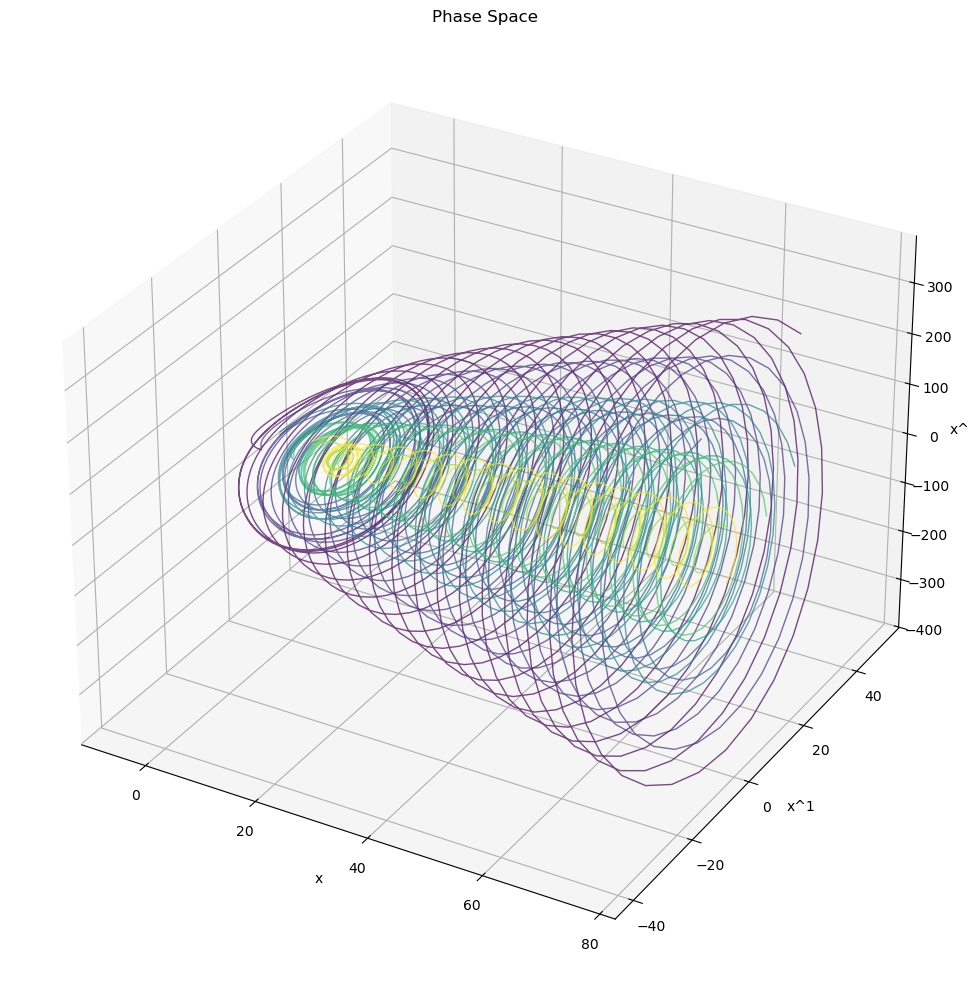

Plotted 8 trajectories.
Projection: [1, 2, 3]
Color by: 0 (time)


In [55]:
# RUNNING AND PLOTTING

if first_order_system:
    system = ODESystemND(system_func, n_vars, var_names)
else:
    system = ODESystemND.from_higher_order(highest_derivative, ode_order, var_names)
ic_grid = []
for i in np.linspace(ic_center[0] - ic_spread, ic_center[0] + ic_spread, num_ics_x):
    for j in np.linspace(ic_center[1] - ic_spread, ic_center[1] + ic_spread, num_ics_y):
        for k in np.linspace(
            ic_center[2] - ic_spread, ic_center[2] + ic_spread, num_ics_z
        ):
            ic_grid.append([i, j, k])
t_eval = np.linspace(t_start, t_end, num_points)
viewer = ODEViewerND()
viewer.solve_ics_grid(system, (t_start, t_end), ic_grid, t_eval=t_eval)
if not save_plot:
    viewer.plot_all_3d(
        projection_axes=projection_axes,
        color_variable=color_by,
        figsize=figsize,
        title=title,
        save_path=save_path if save_plot else None,
    )
else:
    viewer.plot_all_3d(
        projection_axes=projection_axes,
        color_variable=color_by,
        figsize=figsize,
        title=title,
        save_path=save_path if save_plot else None,
    )

print(f"Plotted {len(viewer.solutions)} trajectories.")
print(f"Projection: {projection_axes}")
print(
    f"Color by: {color_by} ({['time', 'x', 'dx/dt', 'd²x/dt²', 'd³x/dt³'][color_by] if color_by < 5 else 'custom'})"
)

In [56]:
# THREE.JS INTERACTIVE VIEWER

plot_obj = sage.Graphics()
for sol, _ in viewer.solutions:
    x, y, z, colors = sol.project_to_3d(projection_axes, color_by)
    points = [[x[i], y[i], z[i]] for i in range(len(x))]
    if multi_color:
        for i in range(0, len(x) - 10, line_seg_len):
            color_val = (colors[i] - colors.min()) / (
                colors.max() - colors.min() + 1e-10
            )
            segment = sage.line3d(
                [[x[i], y[i], z[i]], [x[i + 10], y[i + 10], z[i + 10]]],
                color=sage.hue(color_val),
                thickness=2,
                opacity=0.8,
            )
            plot_obj += segment
    else:
        colors_ic = cm.viridis(np.linspace(0, 1, len(viewer.solutions)))
        for idx, (sol, _) in enumerate(viewer.solutions):
            x, y, z, _ = sol.project_to_3d(projection_axes, color_by)
            points = [[x[i], y[i], z[i]] for i in range(len(x))]
            line = sage.line3d(
                points,
                color=sage.hue(idx / len(viewer.solutions)),
                thickness=2,
                opacity=0.8,
            )
            plot_obj += line

plot_obj.save(threejs_filename, viewer="threejs", online=True)
print(f"Three.js plot saved to: {threejs_filename}")
sage.show(plot_obj)

Three.js plot saved to: ./Plots/3D/solution_3d.html
Graphics3d Object
